In [1]:
import os, glob, random
from collections import deque

import numpy as np
import pretty_midi
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
%matplotlib inline

In [3]:
NOTE_ON_BASE = 0
NOTE_OFF_BASE = 128
TIME_SHIFT_BASE = 256
TIME_SHIFT_BINS = 32
VELOCITY_BASE = 256 + TIME_SHIFT_BINS
VELOCITY_BINS = 16
PAD_ID = VELOCITY_BASE + VELOCITY_BINS
EOS_ID = PAD_ID + 1
VOCAB_SIZE = EOS_ID + 1

TIME_STEP_SECONDS = 0.03125
MAX_TIME_SHIFT_UNITS = TIME_SHIFT_BINS - 1


def _velocity_to_bin(velocity: int) -> int:
    return int(np.clip(velocity, 1, 127) // (128 // VELOCITY_BINS))


def _bin_to_velocity(bin_idx: int) -> int:
    return int(np.clip(bin_idx * (128 // VELOCITY_BINS) + 8, 1, 127))


def midi_to_tokens(path: str, max_len: int = 512) -> np.ndarray:
    pm = pretty_midi.PrettyMIDI(path)
    events = []
    for inst in pm.instruments:
        if inst.is_drum:
            continue
        for note in inst.notes:
            events.append((note.start, "on", note.pitch, note.velocity))
            events.append((note.end, "off", note.pitch, note.velocity))
    events.sort(key=lambda e: (e[0], 0 if e[1] == "off" else 1))

    tokens = []
    last_time = 0.0
    last_vel_bin = -1
    for time, kind, pitch, velocity in events:
        delta = max(0.0, time - last_time)
        remaining_units = int(round(delta / TIME_STEP_SECONDS))
        while remaining_units > 0:
            step = min(remaining_units, MAX_TIME_SHIFT_UNITS)
            tokens.append(TIME_SHIFT_BASE + step)
            remaining_units -= step
        last_time = time

        if kind == "on":
            vel_bin = _velocity_to_bin(velocity)
            if vel_bin != last_vel_bin:
                tokens.append(VELOCITY_BASE + vel_bin)
                last_vel_bin = vel_bin
            tokens.append(NOTE_ON_BASE + pitch)
        else:
            tokens.append(NOTE_OFF_BASE + pitch)

        if len(tokens) >= max_len - 1:
            break

    tokens.append(EOS_ID)
    tokens = tokens[:max_len]
    if len(tokens) < max_len:
        tokens += [PAD_ID] * (max_len - len(tokens))
    return np.array(tokens, dtype=np.int64)


def tokens_to_midi(tokens, tempo_bpm: float = 110.0) -> pretty_midi.PrettyMIDI:
    pm = pretty_midi.PrettyMIDI(initial_tempo=tempo_bpm)
    inst = pretty_midi.Instrument(program=0, name="synth")

    time = 0.0
    velocity = 80
    active_notes = {}

    for tok in tokens:
        tok = int(tok)
        if tok == PAD_ID or tok == EOS_ID:
            continue
        if NOTE_ON_BASE <= tok < NOTE_OFF_BASE:
            pitch = tok - NOTE_ON_BASE
            active_notes[pitch] = (time, velocity)
        elif NOTE_OFF_BASE <= tok < TIME_SHIFT_BASE:
            pitch = tok - NOTE_OFF_BASE
            if pitch in active_notes:
                start, vel = active_notes.pop(pitch)
                if time > start:
                    inst.notes.append(
                        pretty_midi.Note(velocity=vel, pitch=pitch, start=start, end=time)
                    )
        elif TIME_SHIFT_BASE <= tok < VELOCITY_BASE:
            units = tok - TIME_SHIFT_BASE
            time += units * TIME_STEP_SECONDS
        elif VELOCITY_BASE <= tok < PAD_ID:
            velocity = _bin_to_velocity(tok - VELOCITY_BASE)

    for pitch, (start, vel) in active_notes.items():
        inst.notes.append(pretty_midi.Note(velocity=vel, pitch=pitch, start=start, end=time + 0.25))

    pm.instruments.append(inst)
    return pm


def piano_roll_figure(pm: pretty_midi.PrettyMIDI, title: str = "Generated sequence"):
    fig, ax = plt.subplots(figsize=(8, 3.2))
    notes = pm.instruments[0].notes if pm.instruments else []
    if not notes:
        ax.text(0.5, 0.5, "No notes generated", ha="center", va="center")
        ax.set_axis_off()
        return fig

    max_time = max(n.end for n in notes)
    for n in notes:
        alpha = np.clip(n.velocity / 127.0, 0.25, 1.0)
        ax.barh(y=n.pitch, width=n.end - n.start, left=n.start, height=0.8,
                color="#6C5CE7", alpha=alpha, edgecolor="none")
    ax.set_xlim(0, max(max_time, 1.0))
    pitches = [n.pitch for n in notes]
    ax.set_ylim(min(pitches) - 3, max(pitches) + 3)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("MIDI pitch")
    ax.set_title(title)
    fig.tight_layout()
    return fig

In [4]:
def _entropy(counts: np.ndarray) -> float:
    counts = counts[counts > 0]
    if counts.size == 0:
        return 0.0
    probs = counts / counts.sum()
    return float(-(probs * np.log2(probs)).sum())


def pitch_entropy(pm: pretty_midi.PrettyMIDI) -> float:
    notes = pm.instruments[0].notes if pm.instruments else []
    if not notes:
        return 0.0
    pitches = np.array([n.pitch % 12 for n in notes])
    counts = np.bincount(pitches, minlength=12)
    return _entropy(counts)


def rhythm_entropy(pm: pretty_midi.PrettyMIDI, grid: float = 0.125) -> float:
    notes = pm.instruments[0].notes if pm.instruments else []
    if not notes:
        return 0.0
    onsets = np.array([n.start for n in notes])
    bucket = np.mod(np.round(onsets / grid), 32).astype(int)
    counts = np.bincount(bucket, minlength=32)
    return _entropy(counts)


def bass_emphasis(pm: pretty_midi.PrettyMIDI) -> float:
    notes = pm.instruments[0].notes if pm.instruments else []
    if not notes:
        return 0.0
    low = sum(1 for n in notes if n.pitch < 48)
    return low / len(notes)


def attribute_vector(pm: pretty_midi.PrettyMIDI) -> np.ndarray:
    return np.array([pitch_entropy(pm), rhythm_entropy(pm), bass_emphasis(pm)], dtype=np.float32)

In [5]:
ATTR_DIM = 3  # [pitch_entropy, rhythm_entropy, bass_emphasis]


class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, latent_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.to_mu = nn.Linear(hidden_dim * 2, latent_dim)
        self.to_logvar = nn.Linear(hidden_dim * 2, latent_dim)

    def forward(self, tokens):
        x = self.embed(tokens)
        _, (h_n, _) = self.rnn(x)
        h = torch.cat([h_n[-2], h_n[-1]], dim=-1)
        return self.to_mu(h), self.to_logvar(h)


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, latent_dim, attr_dim=ATTR_DIM):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.init_state = nn.Linear(latent_dim + attr_dim, hidden_dim * 2)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, vocab_size)

    def _init_hidden(self, zc):
        h0c0 = torch.tanh(self.init_state(zc))
        h0, c0 = h0c0.chunk(2, dim=-1)
        return h0.unsqueeze(0), c0.unsqueeze(0)

    def forward(self, zc, target_tokens):
        h, c = self._init_hidden(zc)
        x = self.embed(target_tokens)
        out, _ = self.rnn(x, (h, c))
        return self.out(out)

    @torch.no_grad()
    def generate(self, zc, max_len, temperature=1.0):
        dev = zc.device
        batch = zc.shape[0]
        h, c = self._init_hidden(zc)
        token = torch.full((batch, 1), EOS_ID, dtype=torch.long, device=dev)
        generated = []
        for _ in range(max_len):
            x = self.embed(token)
            out, (h, c) = self.rnn(x, (h, c))
            logits = self.out(out[:, -1]) / max(temperature, 1e-4)
            probs = F.softmax(logits, dim=-1)
            token = torch.multinomial(probs, 1)
            generated.append(token)
        return torch.cat(generated, dim=1)


class Discriminator(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), nn.LeakyReLU(0.2), nn.Linear(hidden_dim, 1)
        )

    def forward(self, tokens):
        x = self.embed(tokens)
        _, (h_n, _) = self.rnn(x)
        h = torch.cat([h_n[-2], h_n[-1]], dim=-1)
        return self.head(h).squeeze(-1)


class HybridVAEGAN(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=256, latent_dim=64, attr_dim=ATTR_DIM):
        super().__init__()
        self.latent_dim = latent_dim
        self.attr_dim = attr_dim
        self.encoder = Encoder(vocab_size, embed_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(vocab_size, embed_dim, hidden_dim, latent_dim, attr_dim)
        self.discriminator = Discriminator(vocab_size, embed_dim, hidden_dim)

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, tokens, attrs):
        mu, logvar = self.encoder(tokens)
        z = self.reparameterize(mu, logvar)
        zc = torch.cat([z, attrs], dim=-1)
        return self.decoder(zc, tokens), mu, logvar

    @torch.no_grad()
    def sample(self, attrs, max_len=256, temperature=1.0, z=None):
        dev = attrs.device
        if z is None:
            z = torch.randn(attrs.shape[0], self.latent_dim, device=dev)
        zc = torch.cat([z, attrs], dim=-1)
        tokens = self.decoder.generate(zc, max_len=max_len, temperature=temperature)
        return tokens, z

In [6]:
MIDI_DIR = "data/midi/maestro-v3.0.0"   # folder to search recursively
SEQ_LEN = 256
BATCH_SIZE = 16
LATENT_DIM = 64
EPOCHS = 5
LR_VAE = 2e-4
LR_DISC = 1e-4
KL_WEIGHT = 0.01
ADV_WEIGHT = 0.5
GP_WEIGHT = 10.0
REPLAY_SIZE = 200
CHECKPOINT_OUT = "checkpoint.pt"

In [7]:
class MidiTokenDataset(Dataset):
    def __init__(self, midi_dir: str, seq_len: int = 256):
        paths = glob.glob(os.path.join(midi_dir, "**/*.mid"), recursive=True)
        paths += glob.glob(os.path.join(midi_dir, "**/*.midi"), recursive=True)
        self.paths = sorted(set(paths))
        if not self.paths:
            raise FileNotFoundError(f"No .mid or .midi files found under {midi_dir}")
        self.seq_len = seq_len

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        tokens = midi_to_tokens(path, max_len=self.seq_len)
        pm = tokens_to_midi(tokens)
        attrs = attribute_vector(pm)
        attrs = attrs / np.array([3.5, 5.0, 1.0], dtype=np.float32)
        return torch.from_numpy(tokens), torch.from_numpy(attrs)


dataset = MidiTokenDataset(MIDI_DIR, seq_len=SEQ_LEN)
print(f"Found {len(dataset)} MIDI files")

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

Found 1276 MIDI files


token sequence shape: torch.Size([256])
attribute vector (pitch_ent, rhythm_ent, bass_emph, normalised): [0.82169676 0.91708386 0.        ]


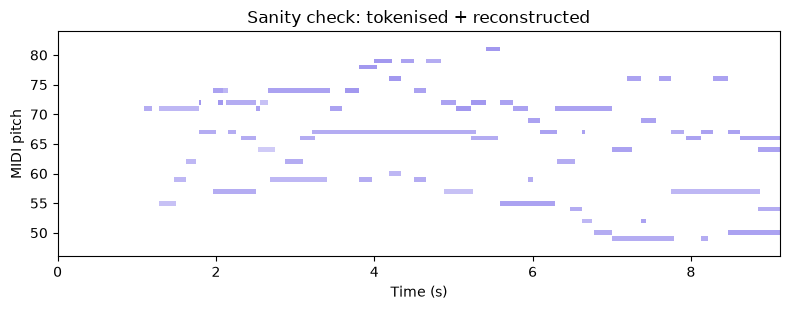

In [8]:
sample_tokens, sample_attrs = dataset[0]
print("token sequence shape:", sample_tokens.shape)
print("attribute vector (pitch_ent, rhythm_ent, bass_emph, normalised):", sample_attrs.numpy())

pm_check = tokens_to_midi(sample_tokens.numpy())
fig = piano_roll_figure(pm_check, title="Sanity check: tokenised + reconstructed")
plt.show()

In [9]:
model = HybridVAEGAN(latent_dim=LATENT_DIM).to(device)
opt_vae = torch.optim.Adam(
    list(model.encoder.parameters()) + list(model.decoder.parameters()), lr=LR_VAE
)
opt_disc = torch.optim.Adam(model.discriminator.parameters(), lr=LR_DISC)
replay_buffer = deque(maxlen=REPLAY_SIZE)

hybrid_loss_history = []
disc_loss_history = []
print("Model built. Parameters:", sum(p.numel() for p in model.parameters()))

Model built. Parameters: 2404531


In [10]:
def gradient_penalty(discriminator, real_tokens, fake_tokens, device):
    batch = real_tokens.shape[0]
    real_emb = discriminator.embed(real_tokens)
    fake_emb = discriminator.embed(fake_tokens).detach()
    eps = torch.rand(batch, 1, 1, device=device)
    interp = (eps * real_emb + (1 - eps) * fake_emb).requires_grad_(True)
    out, _ = discriminator.rnn(interp)
    h = out[:, -1]
    score = discriminator.head(h).sum()
    grads = torch.autograd.grad(score, interp, create_graph=True)[0]
    grad_norm = grads.reshape(batch, -1).norm(2, dim=1)
    return ((grad_norm - 1) ** 2).mean()

real_label_smooth = 0.9
print(f"Total batches per epoch: {len(loader)}")

for epoch in range(EPOCHS):
    epoch_vae_loss = epoch_disc_loss = 0.0
    for batch_idx, (tokens, attrs) in enumerate(loader):
        tokens, attrs = tokens.to(device), attrs.to(device)
        logits, mu, logvar = model(tokens, attrs)
        recon_loss = F.cross_entropy(
            logits.reshape(-1, logits.shape[-1]), tokens.reshape(-1), ignore_index=PAD_ID
        )
        kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        with torch.no_grad():
            fake_tokens, _ = model.sample(attrs, max_len=SEQ_LEN, temperature=1.0)
        if replay_buffer and random.random() < 0.5:
            disc_fake_input = replay_buffer[random.randrange(len(replay_buffer))].to(device)
        else:
            disc_fake_input = fake_tokens
        replay_buffer.append(fake_tokens.detach().cpu())
        real_logits = model.discriminator(tokens)
        fake_logits = model.discriminator(disc_fake_input.detach())
        real_targets = torch.full_like(real_logits, real_label_smooth)
        fake_targets = torch.zeros_like(fake_logits)
        gp = gradient_penalty(model.discriminator, tokens, disc_fake_input, device)
        disc_loss = (
            F.binary_cross_entropy_with_logits(real_logits, real_targets)
            + F.binary_cross_entropy_with_logits(fake_logits, fake_targets)
            + GP_WEIGHT * gp
        )
        opt_disc.zero_grad()
        disc_loss.backward()
        opt_disc.step()
        adv_logits = model.discriminator(fake_tokens)
        adv_loss = F.binary_cross_entropy_with_logits(adv_logits, torch.ones_like(adv_logits))
        hybrid_loss = recon_loss + KL_WEIGHT * kl_loss + ADV_WEIGHT * adv_loss
        opt_vae.zero_grad()
        hybrid_loss.backward()
        opt_vae.step()
        epoch_vae_loss += hybrid_loss.item()
        epoch_disc_loss += disc_loss.item()
        if batch_idx % 2 == 0:
            print(f"  epoch {epoch+1} batch {batch_idx}/{len(loader)}  hybrid={hybrid_loss.item():.4f}  disc={disc_loss.item():.4f}")
    avg_vae = epoch_vae_loss / len(loader)
    avg_disc = epoch_disc_loss / len(loader)
    hybrid_loss_history.append(avg_vae)
    disc_loss_history.append(avg_disc)
    print(f"epoch {epoch + 1}/{EPOCHS}  hybrid_loss={avg_vae:.4f}  disc_loss={avg_disc:.4f}")

Total batches per epoch: 79
  epoch 1 batch 0/79  hybrid=6.0493  disc=10.8993
  epoch 1 batch 2/79  hybrid=6.0204  disc=10.7960
  epoch 1 batch 4/79  hybrid=5.9874  disc=10.6931
  epoch 1 batch 6/79  hybrid=5.9556  disc=10.5736
  epoch 1 batch 8/79  hybrid=5.9272  disc=10.4325
  epoch 1 batch 10/79  hybrid=5.9041  disc=10.2747
  epoch 1 batch 12/79  hybrid=5.8718  disc=10.1085
  epoch 1 batch 14/79  hybrid=5.8412  disc=9.9812
  epoch 1 batch 16/79  hybrid=5.7993  disc=9.8523
  epoch 1 batch 18/79  hybrid=5.7624  disc=9.6230
  epoch 1 batch 20/79  hybrid=5.7204  disc=9.4753
  epoch 1 batch 22/79  hybrid=5.6820  disc=9.2581
  epoch 1 batch 24/79  hybrid=5.6643  disc=8.9315
  epoch 1 batch 26/79  hybrid=5.5939  disc=8.6599
  epoch 1 batch 28/79  hybrid=5.5026  disc=8.4277
  epoch 1 batch 30/79  hybrid=5.4232  disc=8.1901
  epoch 1 batch 32/79  hybrid=5.3401  disc=7.9178
  epoch 1 batch 34/79  hybrid=5.2670  disc=7.5387
  epoch 1 batch 36/79  hybrid=5.0056  disc=7.0141
  epoch 1 batch 38/7

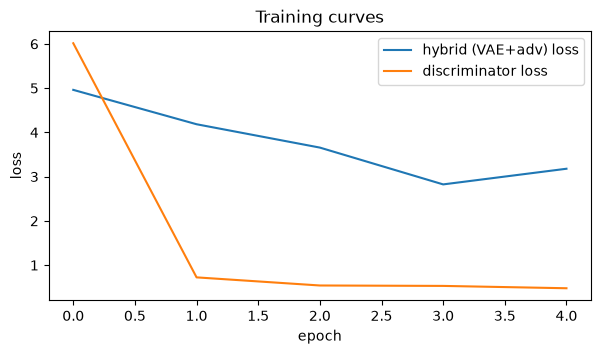

In [11]:
plt.figure(figsize=(7, 3.5))
plt.plot(hybrid_loss_history, label="hybrid (VAE+adv) loss")
plt.plot(disc_loss_history, label="discriminator loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Training curves")
plt.show()

In [12]:
torch.save({"model_state": model.state_dict(), "latent_dim": LATENT_DIM}, CHECKPOINT_OUT)
print(f"Saved checkpoint to {CHECKPOINT_OUT}")

Saved checkpoint to checkpoint.pt


Generated notes: 11
Pitch entropy: 3.095795255000934  Rhythm entropy: 1.9362600275315274


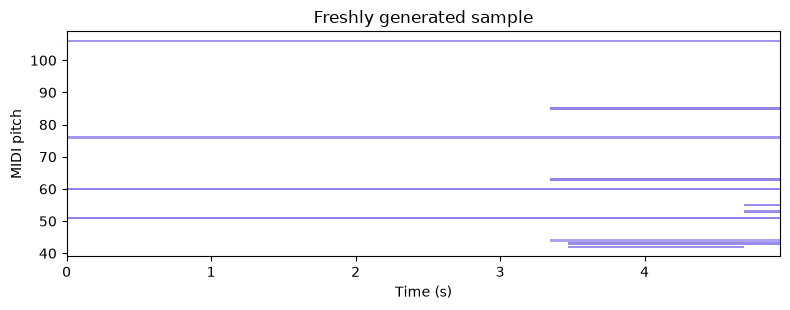

Wrote notebook_sample_output.mid


In [13]:
model.eval()
test_attrs = torch.tensor([[0.5, 0.5, 0.3]], device=device)  # [pitch_ent, rhythm_ent, bass_emph], normalised
with torch.no_grad():
    gen_tokens, z = model.sample(test_attrs, max_len=SEQ_LEN, temperature=1.0)

pm_out = tokens_to_midi(gen_tokens[0].cpu().numpy())
print("Generated notes:", len(pm_out.instruments[0].notes) if pm_out.instruments else 0)
print("Pitch entropy:", pitch_entropy(pm_out), " Rhythm entropy:", rhythm_entropy(pm_out))

fig = piano_roll_figure(pm_out, title="Freshly generated sample")
plt.show()

pm_out.write("notebook_sample_output.mid")
print("Wrote notebook_sample_output.mid")

## Launch the interactive prototype

Run this from a terminal (not from inside this notebook — Streamlit needs its own process):

```bash
streamlit run streamlit_app.py
```